# Bussiness Problem

“Many online job portals have fake job postings which can scam users. This dataset helps build a model to automatically detect fraudulent job postings, improving user trust and platform safety.”

# What I observed from this dataset

Most entries have fraudulent = 0 → dataset is imbalanced
Data contains text-heavy columns (description, requirements, etc.)
Some columns may have missing values
This is a mix of:
    1) **Text data (NLP)**
    2) **Categorical data**
    3) **Binary data**

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("fake_job_postings.csv")
df.tail()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0
17879,17880,Web Application Developers,"NZ, N, Wellington",Engineering,NaN,Vend is looking for some awesome new talent to...,Who are we?Vend is an award winning web based ...,We want to hear from you if:You have an in-dep...,NaN,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Engineering,0


In [3]:
df.shape

(17880, 18)

**Insights:**
👉 The size
Rows: 17,880,
Columns: 18

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

**INSIGHTS**

  1) **The dataset contains 17,880 rows and 18 columns**
  2) **The dataset is a combination of structured + unstructured data, making it suitable for NLP-based classification**
  3) **The Target variable is a binary classification problem**

In [5]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


**INSIGHTS**

  1) **No missing values in numerical columns like telecommuting, has_company_logo, has_questions, and fraudulent**
  2) **Target Variable Distribution Most jobs are real, very few are fraudulent**
  3) **Very few jobs are remote,Remote jobs might be suspicious or rare**
  3) **Most jobs have company logos Jobs without logos may be suspicious**
  4) **Around half of jobs include screening questions Presence/absence may help detect fake jobs**

In [6]:
df.drop('job_id', axis=1, inplace=True)

**INSIGHTS**

  1) **Just an identifier → not useful for model**

In [7]:
df.isnull().sum()/len(df)*100

title                   0.000000
location                1.935123
department             64.580537
salary_range           83.959732
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64

**INSIGHTS**

  1) **Core features and target variable are complete and reliable**
  2) **Salary_range and Department these columns have too many missing values, so they were dropped during preprocessing**
  3) **benefits,required_education,required_experience,function these columns have significant missing values, so they were handled using imputation
     filled with default values like “Not Available”**
  3) **company_profile,requirements,employment_type,industry these columns were important features, so missing values were filled instead of dropping**
  4) **location,description these columns are almost complete, so minimal preprocessing required**

In [8]:
df.drop(['salary_range', 'department'], axis=1, inplace=True)
df.isnull().sum()/len(df)*100

title                   0.000000
location                1.935123
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64

**INSIGHTS**

  1) **Columns with very high missing values were removed to reduce noise and improve model quality**

In [9]:
num_cols = df.select_dtypes(include = "int64").columns
cat_cols = df.select_dtypes(include = "object").columns


print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent'], dtype='object')
Categorical Columns: Index(['title', 'location', 'company_profile', 'description', 'requirements',
       'benefits', 'employment_type', 'required_experience',
       'required_education', 'industry', 'function'],
      dtype='object')


In [10]:
df[cat_cols] = df[cat_cols].fillna('Not Available')

In [11]:
df.isnull().sum()

title                  0
location               0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

**INSIGHTS**

  1) **So here we see the null values are handled**

In [12]:
df.duplicated().sum()

np.int64(290)

In [13]:
df = df.drop_duplicates()

**INSIGHTS**

  1) **In my dataset there were 290 duplicates i drop them**

# 1.Univariate Analysis

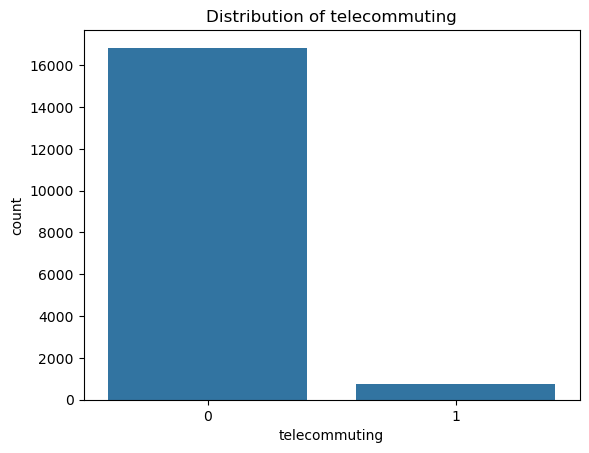

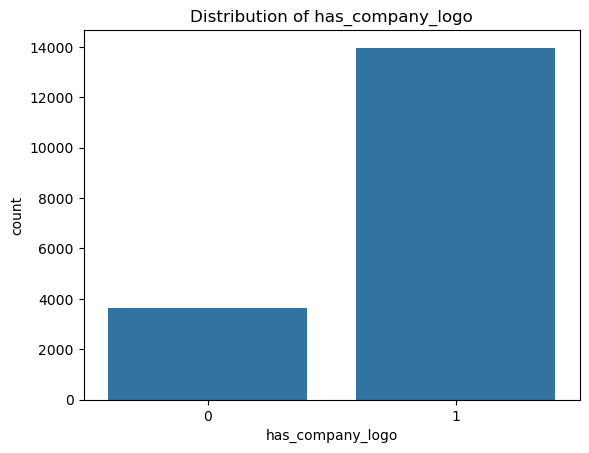

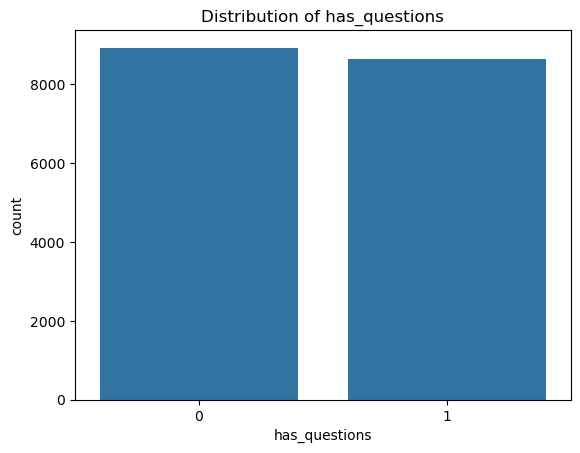

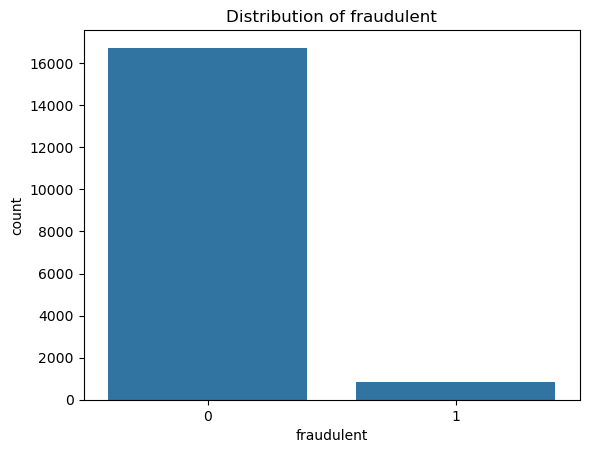

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

**INSIGHTS**

  1) **Most job postings are not remote, and remote jobs are very limited.This may indicate that remote jobs can be slightly suspicious or less common**
  2) **Most companies provide logos, so jobs without logos may indicate fake postings**
  3) **Screening questions are almost balanced**
  3) **The dataset is highly imbalanced, with very few fraudulent jobs**
  4) **Around half of jobs include screening questions Presence/absence may help detect fake jobs**

# 2.Bivariate Analysis

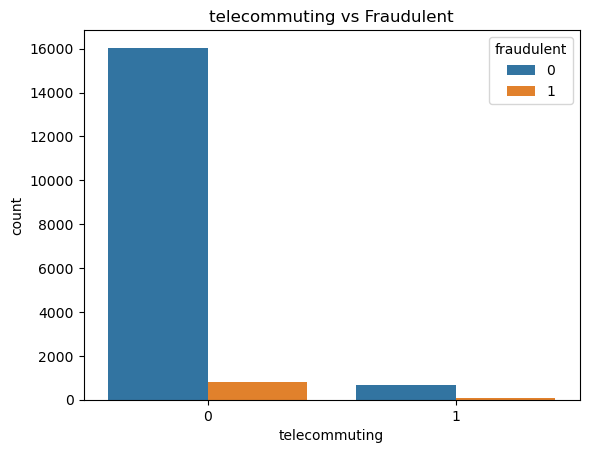

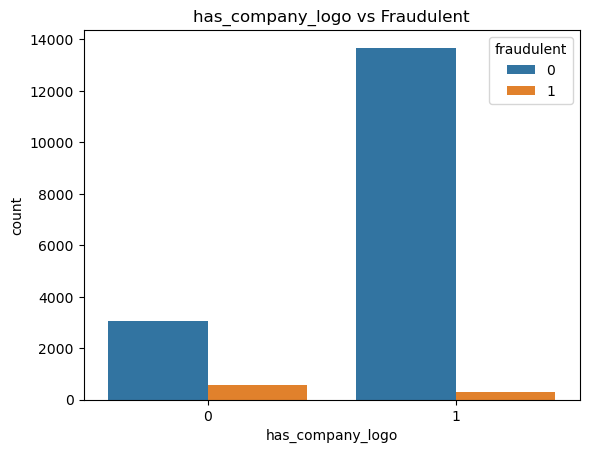

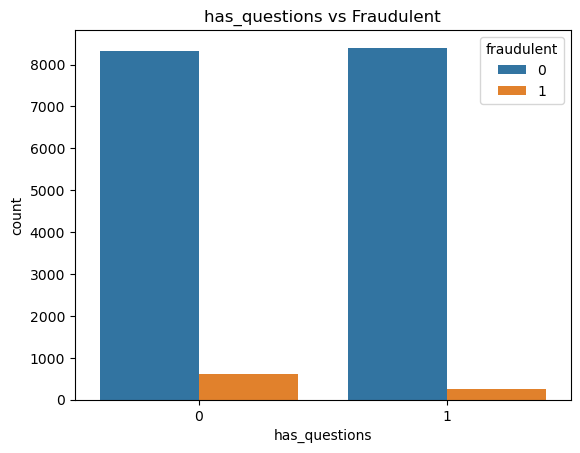

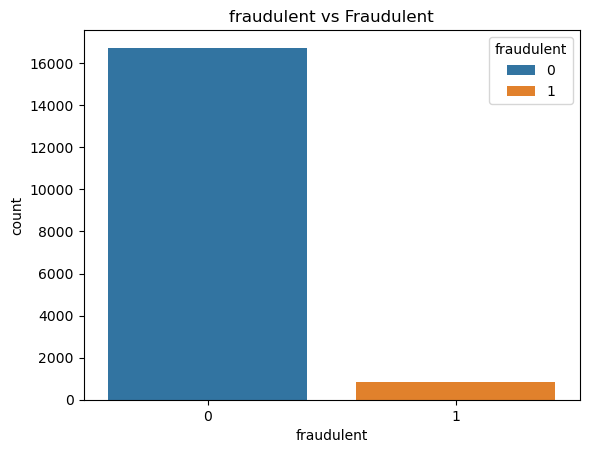

In [15]:
for col in num_cols:
    sns.countplot(x=col, hue='fraudulent', data=df)
    plt.title(f"{col} vs Fraudulent")
    plt.show()

**INSIGHTS**

  1) **Features like company logo and screening questions show meaningful patterns, while telecommuting has limited impact. These relationships helped         in selecting important features for model training**

# 3.Multivariate Analysis

<Axes: xlabel='required_experience', ylabel='count'>

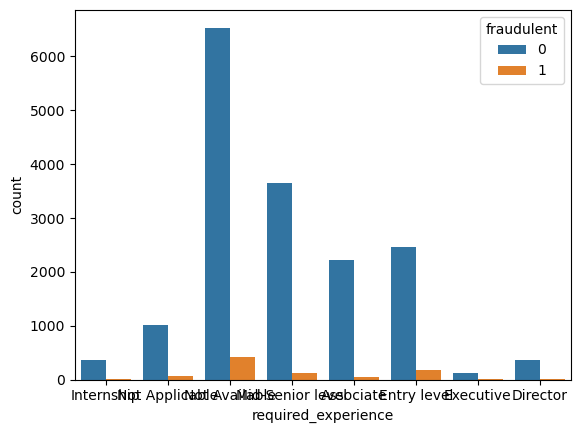

In [16]:
sns.countplot(x='required_experience', hue='fraudulent', data=df)

**INSIGHTS**

  1) **Fraudulent jobs tend to target low-experience candidates and avoid high-level roles, which helps in identifying risk patterns**

In [17]:
corr = df[num_cols].corr()
corr

,telecommuting,has_company_logo,has_questions,fraudulent
telecommuting,1.000000,-0.021776,0.019979,0.035879
has_company_logo,-0.021776,1.000000,0.233798,-0.259829
has_questions,0.019979,0.233798,1.000000,-0.090976
fraudulent,0.035879,-0.259829,-0.090976,1.000000


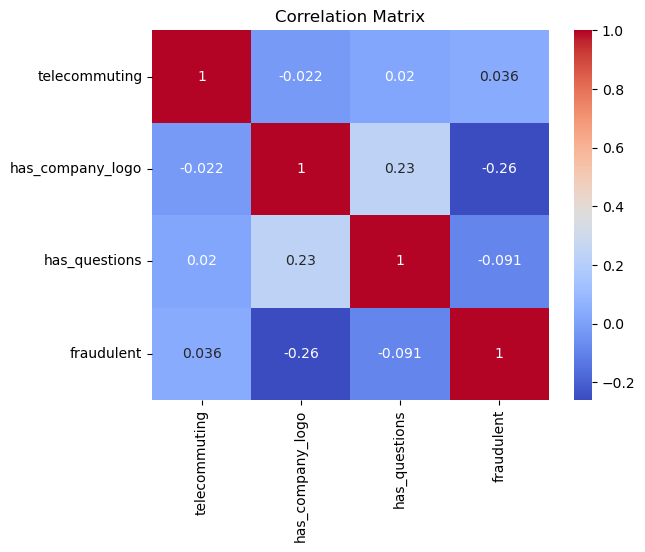

In [18]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**INSIGHTS**

  1) **Structured features have weak correlations with fraud, so textual features like job description play a major role in prediction.**

**EDA INSIGHTS**

  1) **Dataset is highly imbalanced**
  2) **Fake jobs often lack company logos**
  3) **Remote jobs have higher fraud probability**
  4) **Fake job descriptions are shorter and less detailed**
  5) **Text features play a major role in classification**

In [19]:
df['text'] = df['title'] + " " + \
             df['description'] + " " + \
             df['requirements'] + " " + \
             df['company_profile'] + " " + \
             df['employment_type'] + " " + \
             df['required_experience'] + " " + \
             df['required_education'] + " " + \
             df['industry'] + " " + \
             df['function']

**INSIGHTS**

  1) **Multiple text columns were combined into a single feature to capture complete job information in one place**

In [20]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

**INSIGHTS**

  1) **Combining multiple text features and applying NLP preprocessing improves model performance by capturing meaningful patterns and reducing noise.**

In [21]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # remove numbers/symbols
    words = text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

In [22]:
df['clean_text'] = df['text'].apply(preprocess_text)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    min_df=5,
    max_df=0.8,
    ngram_range=(1,2),          
    token_pattern=r'[a-zA-Z]+'
)

In [24]:
X = df['clean_text']   # ✅ text only
y = df['fraudulent']

In [25]:
X.shape

(17590,)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [28]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=2000)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

In [29]:
print(X_train.shape)
print(X_test.shape)

(14072, 2000)
(3518, 2000)


In [30]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
fraudulent
0    13401
1      671
Name: count, dtype: int64


In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "xgboost": XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=6)
}

In [34]:
for name, model in models.items():
    print(f"\n{name}")
    print("-"*30)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
------------------------------
Accuracy: 0.9548038658328596
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3333
           1       0.54      0.88      0.67       185

    accuracy                           0.95      3518
   macro avg       0.77      0.92      0.82      3518
weighted avg       0.97      0.95      0.96      3518


Naive Bayes
------------------------------
Accuracy: 0.8854462762933485
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      3333
           1       0.30      0.89      0.45       185

    accuracy                           0.89      3518
   macro avg       0.65      0.89      0.69      3518
weighted avg       0.96      0.89      0.91      3518


Random Forest
------------------------------
Accuracy: 0.9832291074474133
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3333
        

In [35]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

import pandas as pd
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.954804
1          Naive Bayes  0.885446
2        Random Forest  0.983229
3              xgboost  0.984082


In [36]:
from sklearn.metrics import roc_auc_score

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

for name, model in models.items():
    print(f"\n{name}")
    print("="*40)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # For ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Logistic Regression
Accuracy: 0.9548038658328596
ROC-AUC: 0.9773988209631774

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98      3333
           1       0.54      0.88      0.67       185

    accuracy                           0.95      3518
   macro avg       0.77      0.92      0.82      3518
weighted avg       0.97      0.95      0.96      3518


Confusion Matrix:
 [[3197  136]
 [  23  162]]

Naive Bayes
Accuracy: 0.8854462762933485
ROC-AUC: 0.9574476366555575

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.94      3333
           1       0.30      0.89      0.45       185

    accuracy                           0.89      3518
   macro avg       0.65      0.89      0.69      3518
weighted avg       0.96      0.89      0.91      3518


Confusion Matrix:
 [[2951  382]
 [  21  164]]

Random Forest
Accuracy: 0.9832291074474133
ROC-AUC: 0

In [44]:
from xgboost import XGBClassifier

best_model = XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=6)
best_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [45]:
selected_features = tfidf.get_feature_names_out()[selector.get_support()]

In [46]:
X_df = pd.DataFrame(
    X_train.toarray(),
    columns=selected_features
)

In [47]:
X_df.head()

,ab,ab ea,ability,ability manage,ability multi,ability work,able,able perform,able work,abroad,...,x,xml,year client,yeast,yes,york,york city,young,youth,zealand
0,0.0,0.0,0.030348,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.061985,0.0,0.0
2,0.0,0.0,0.052593,0.0,0.0,0.0,0.031857,0.0,0.050979,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.055195,0.0,0.0,0.046587,0.0,0.000000,0.0,0.0


In [48]:
import pickle

pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(selector, open("selector.pkl", "wb"))
pickle.dump(best_model, open("model.pkl", "wb"))

In [49]:
print("After SMOTE:")
print(y_train.value_counts())

After SMOTE:
fraudulent
0    13401
1    13401
Name: count, dtype: int64
